In [5]:
import warnings
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2
from sklearn.metrics import auc, classification_report, confusion_matrix, roc_curve
from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

## Data Clean

In [6]:
colnames = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race", "sex",
    "capital_gain", "capital_loss", "hours_per_week", "native_country", "income",
]
adult = pd.read_csv("./data/adult.data", header=None, names=colnames, skipinitialspace=True)
adult["occupation"] = adult["occupation"].replace("?", np.nan)
adult["workclass"] = adult["workclass"].replace("?", np.nan)
adult["native_country"] = adult["native_country"].replace("?", np.nan)
adult["income"] = adult["income"].astype(str).map({"<=50K": 0, ">50K": 1})
adult = adult.drop(columns=["fnlwgt", "education_num"])
adult

,age,workclass,education,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,0
1,50,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,0
2,38,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,0
3,53,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,0
4,28,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,Assoc-acdm,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,0
32557,40,Private,HS-grad,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,1
32558,58,Private,HS-grad,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,0
32559,22,Private,HS-grad,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,0


In [7]:
def create_plot(data: pd.DataFrame, var_name: str, plot_type: str = "prop"):
    counts = (
        data.groupby([var_name, "income"], observed=False)
        .size()
        .reset_index(name="n")
    )

    wide = counts.pivot(index=var_name, columns="income", values="n").fillna(0)
    wide = wide.reindex(columns=[0, 1], fill_value=0)

    if plot_type == "count":
        plot_data = wide
        colors = ["#E4381B", "#4CAF50"]
        ylabel = "count"
        ax = plot_data.plot(kind="bar", stacked=False, color=colors, figsize=(9, 4))
    else:
        plot_data = wide.div(wide.sum(axis=1), axis=0)
        colors = ["#F44336", "#4CAF50"]
        ylabel = "proportion"
        ax = plot_data.plot(kind="bar", stacked=True, color=colors, figsize=(9, 4))

    ax.set_xlabel(var_name)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=45)
    ax.get_legend().remove()
    plt.tight_layout()
    plt.show()

def make_region(country: str):
    if pd.isna(country):
        return np.nan
    north_america = {
        "Canada", "United-States", "Mexico", "Cuba", "Dominican-Republic", "Jamaica", "Puerto-Rico",
        "Haiti", "Guatemala", "Honduras", "Nicaragua", "El-Salvador", "Trinadad&Tobago", "Outlying-US(Guam-USVI-etc)"
    }
    south_america = {"Columbia", "Ecuador", "Peru"}
    europe = {"England", "France", "Germany", "Greece", "Holand-Netherlands", "Hungary", "Ireland", "Italy", "Poland", "Portugal", "Scotland", "Yugoslavia"}
    asia = {"Cambodia", "China", "Hong", "India", "Iran", "Japan", "Laos", "Philippines", "Taiwan", "Thailand", "Vietnam", "South"}

    if country in north_america:
        return "North America"
    if country in south_america:
        return "South America"
    if country in europe:
        return "Europe"
    if country in asia:
        return "Asia"
    return np.nan


def make_education_category(education):
    if education in {"1st-4th", "5th-6th"}:
        return "Primary"
    if education in {"7th-8th", "HS-grad", "10th", "11th", "12th", "9th"}:
        return "Secondary"
    if education in {"Some-college", "Bachelors", "Assoc-voc", "Assoc-acdm"}:
        return "Tertiary"
    if education in {"Masters", "Doctorate", "Prof-school"}:
        return "Advanced"
    return "None"


def make_marital_category(status):
    if status in {"Married-civ-spouse", "Married-AF-spouse", "Married-spouse-absent"}:
        return "Married"
    if status in {"Divorced", "Separated", "Widowed"}:
        return "Ex-Married"
    if status == "Never-married":
        return "Never Married"
    return "Other"


def make_occupation_group(occupation):
    if occupation in {"Tech-support", "Craft-repair", "Other-service", "Sales", "Exec-managerial", "Protective-serv", "Priv-house-serv"}:
        return "Service/Tech"
    if occupation in {"Prof-specialty", "Adm-clerical", "Armed-Forces"}:
        return "Professional/Admin"
    if occupation in {"Machine-op-inspct", "Transport-moving", "Farming-fishing", "Handlers-cleaners"}:
        return "Manual Labor"
    return np.nan


def make_workclass_group(workclass):
    if workclass in {"Federal-gov", "Local-gov", "State-gov"}:
        return "Government"
    if workclass in {"Self-emp-inc", "Self-emp-not-inc"}:
        return "Self-employed"
    if workclass == "Private":
        return "Private"
    return np.nan

In [8]:
adult["region"] = adult["native_country"].apply(make_region)

adult["age_category"] = pd.cut(
    adult["age"],
    bins=[0, 25, 35, 45, 55, 65, np.inf],
    labels=["0-24", "25-34", "35-44", "45-54", "55-64", "65+"],
    right=False,
)
adult= adult.drop(columns=["age"])

adult["education_category"] = adult["education"].apply(make_education_category)
adult["education_category"] = pd.Categorical(
    adult["education_category"],
    categories=["None", "Primary", "Secondary", "Tertiary", "Advanced"],
    ordered=True,
)

adult["marital_category"] = adult["marital_status"].apply(make_marital_category)
adult["occupation_group"] = adult["occupation"].apply(make_occupation_group)
adult["workclass_grp"] = adult["workclass"].apply(make_workclass_group)

adult["has_sold_stocks"] = np.where(
    (adult["capital_gain"] > 0) | (adult["capital_loss"] > 0), 1, 0
)
adult = adult.drop(columns=["capital_gain", "capital_loss"])
adult = adult[~adult["education_category"].isin(["Primary", "None"])].copy()
adult["education_category"]= adult["education_category"].cat.remove_categories(["Primary", "None"])


adult.head()

,workclass,education,marital_status,occupation,relationship,race,sex,hours_per_week,native_country,income,region,age_category,education_category,marital_category,occupation_group,workclass_grp,has_sold_stocks
0,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,40,United-States,0,North America,35-44,Tertiary,Never Married,Professional/Admin,Government,1
1,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,13,United-States,0,North America,45-54,Tertiary,Married,Service/Tech,Self-employed,0
2,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,40,United-States,0,North America,35-44,Secondary,Ex-Married,Manual Labor,Private,0
3,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,40,United-States,0,North America,45-54,Secondary,Married,Manual Labor,Private,0
4,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,40,Cuba,0,North America,25-34,Tertiary,Married,Professional/Admin,Private,0


In [9]:
print("Missing values before filtering:")
print(adult.isna().sum())

print("\nNew category frequencies:")
for c in ["region", "age_category", "education_category", "marital_category", "occupation_group", "workclass_grp"]:
    print(f"\n{c}")
    print(adult[c].value_counts(dropna=False))
adult_with_na = adult.copy()
adult = adult.dropna(subset=["occupation_group", "workclass_grp", "region"]).copy()
removed_ratio = (len(adult_with_na) - len(adult)) / len(adult_with_na)
print(f"Istryneme tiek reiksmiu:{removed_ratio:.4%}")

Missing values before filtering:
workclass             1789
education                0
marital_status           0
occupation            1796
relationship             0
race                     0
sex                      0
hours_per_week           0
native_country         562
income                   0
region                 562
age_category             0
education_category       0
marital_category         0
occupation_group      1796
workclass_grp         1810
has_sold_stocks          0
dtype: int64

New category frequencies:

region
region
North America    30109
Asia               728
NaN                562
Europe             496
South America      114
Name: count, dtype: int64

age_category
age_category
25-34    8364
35-44    8043
45-54    5736
0-24     5504
55-64    3080
65+      1282
Name: count, dtype: int64

education_category
education_category
Tertiary     15095
Secondary    14202
Advanced      2712
Name: count, dtype: int64

marital_category
marital_category
Married          1

In [10]:
print("\nIncome class share:")
print(adult["income"].value_counts(normalize=True))


Income class share:
income
0    0.747505
1    0.252495
Name: proportion, dtype: float64


## Pradine duomenu analize

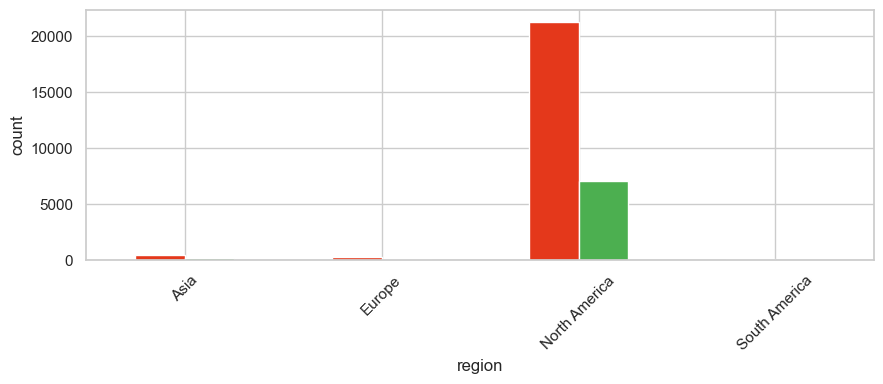

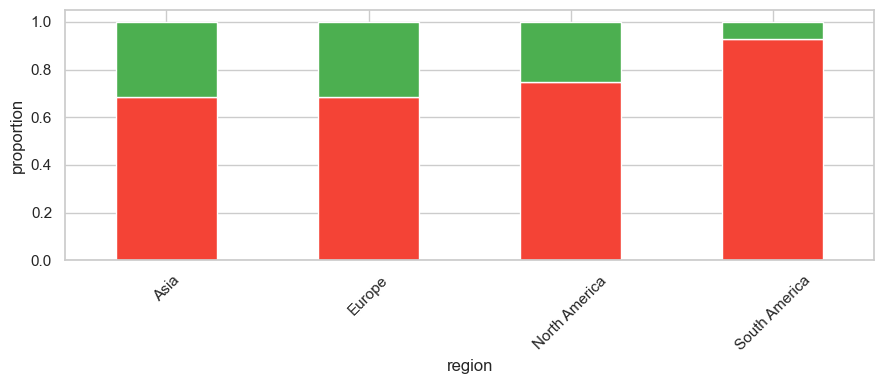

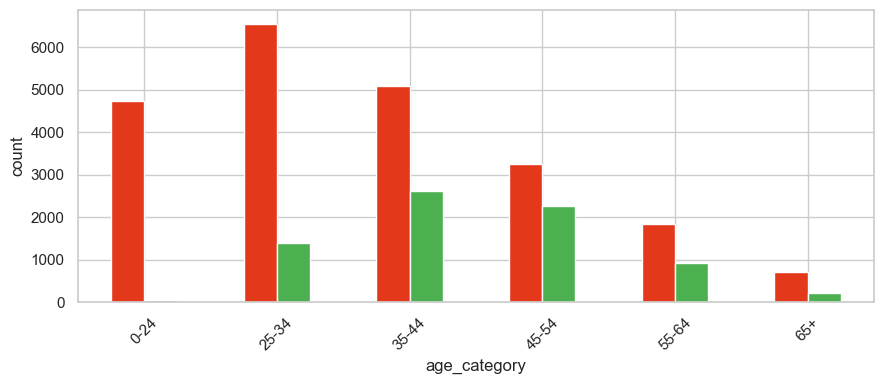

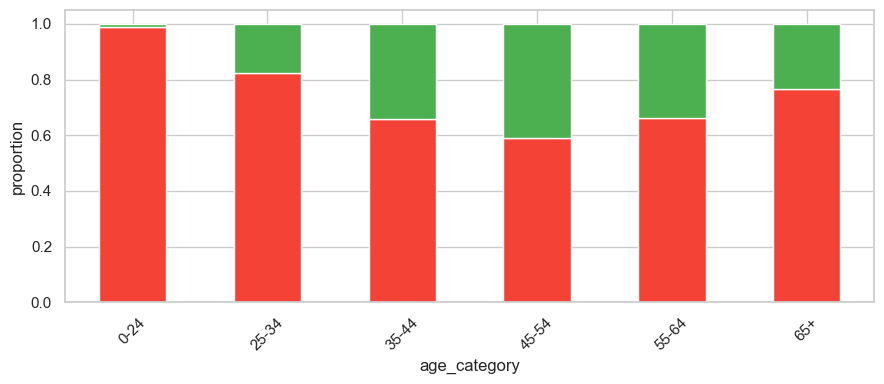

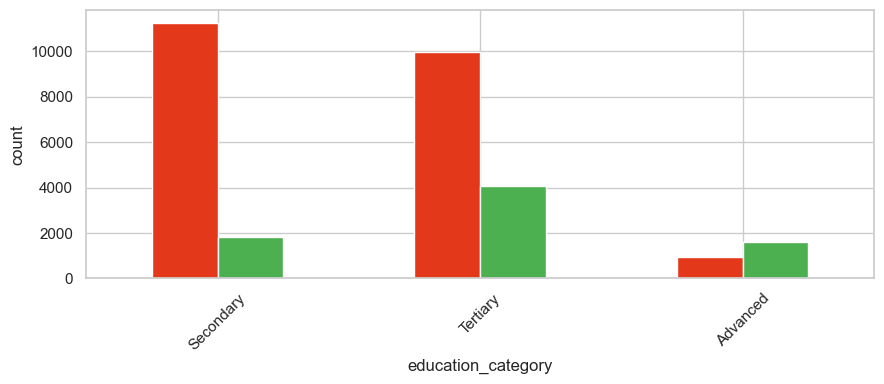

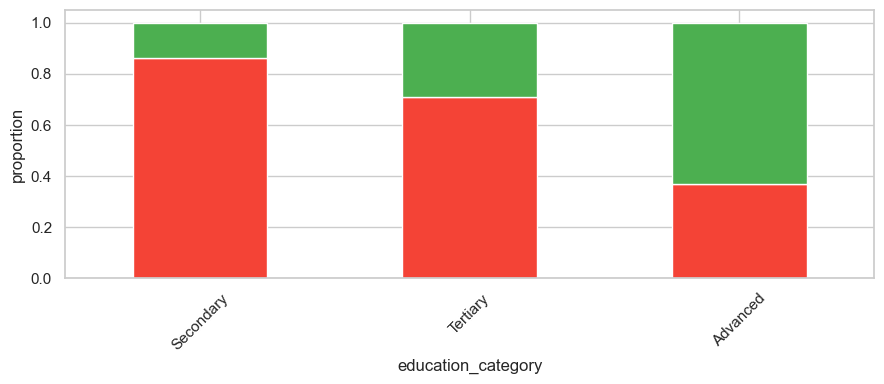

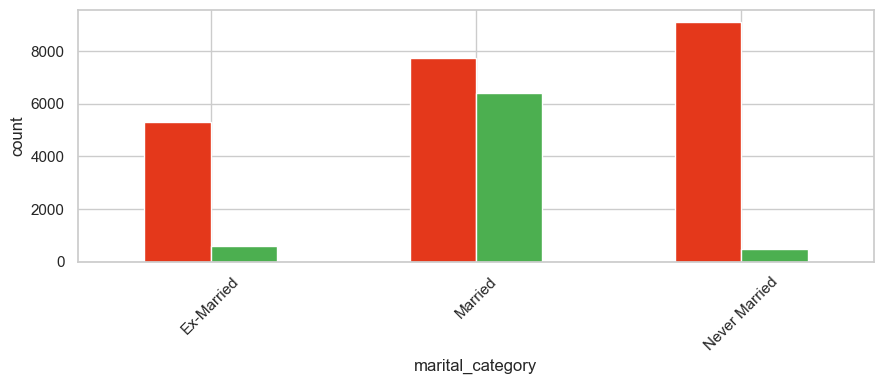

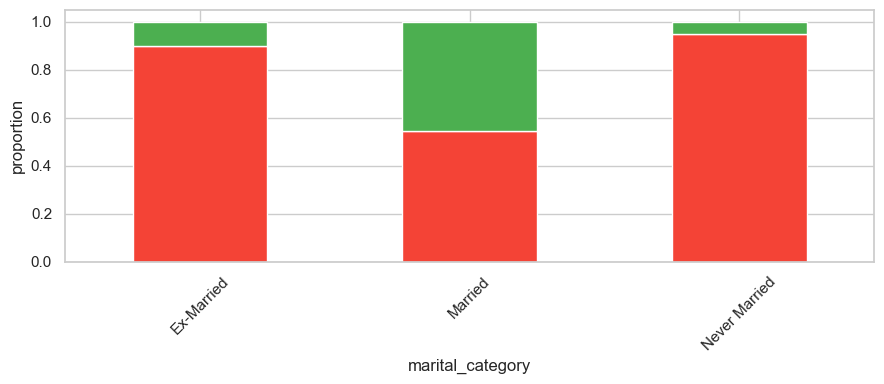

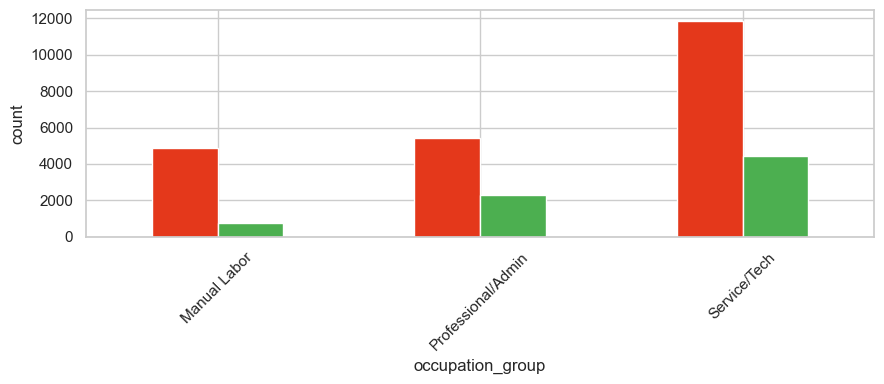

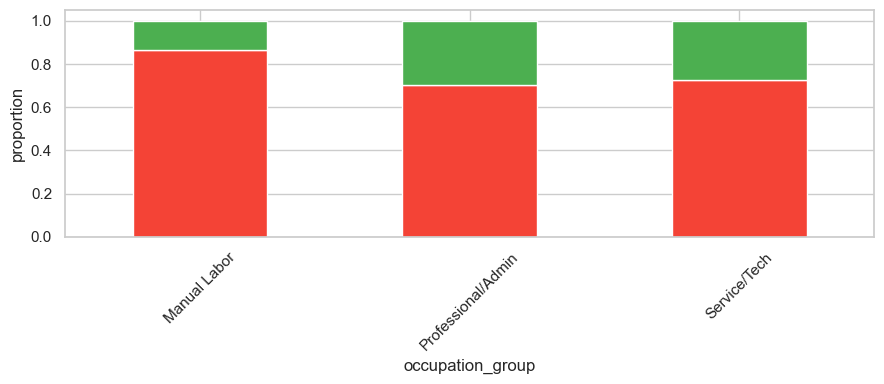

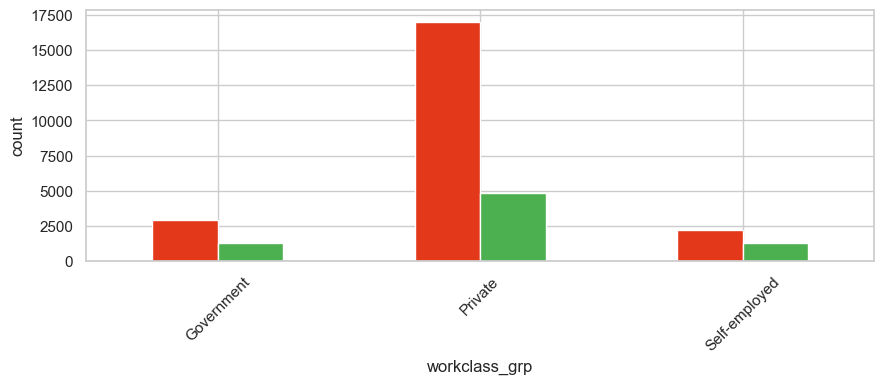

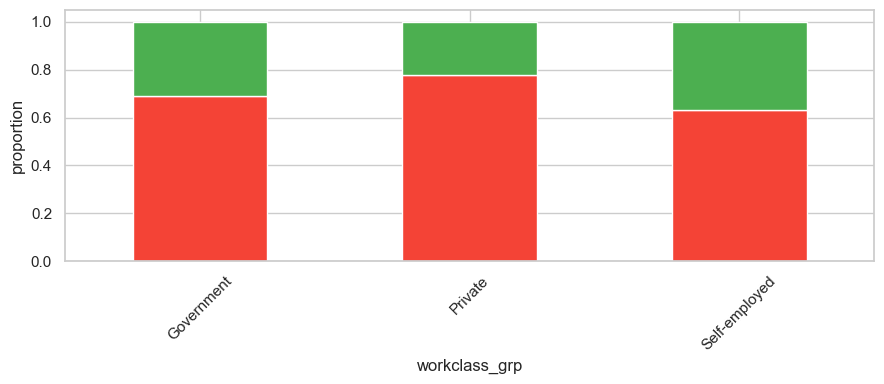

In [11]:
create_plot(adult, "region", plot_type="count")
create_plot(adult, "region", plot_type="prop")
create_plot(adult, "age_category", plot_type="count")
create_plot(adult, "age_category", plot_type="prop")
create_plot(adult, "education_category", plot_type="count")
create_plot(adult, "education_category", plot_type="prop")
create_plot(adult, "marital_category", plot_type="count")
create_plot(adult, "marital_category", plot_type="prop")
create_plot(adult, "occupation_group", plot_type="count")
create_plot(adult, "occupation_group", plot_type="prop")
create_plot(adult, "workclass_grp", plot_type="count")
create_plot(adult, "workclass_grp", plot_type="prop")

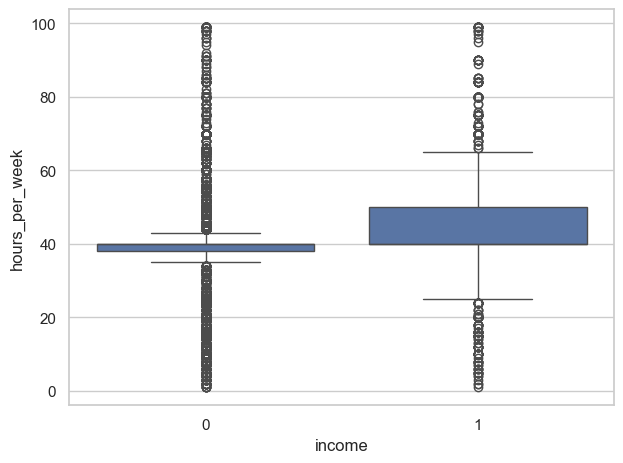

In [12]:
sns.boxplot(data=adult, x="income", y="hours_per_week")
plt.tight_layout()
plt.show()

In [ ]:
adult_clean = adult.drop(
    columns=["education", "marital_status", "native_country", "relationship", "occupation", "workclass"]
).copy()

train, test = train_test_split(
    adult_clean,
    test_size=0.2,
    random_state=80085,
    stratify=adult_clean["income"],
)
print(adult_clean["income"].value_counts())
def calculate_GVIF(all_vars, var, eps=1e-12):
    A_df = pd.get_dummies(all_vars[[var]], drop_first=True, dtype=float)
    if A_df.shape[1] == 0:
        return np.nan

    A = A_df.corr().to_numpy()
    other_cols = [c for c in all_vars.columns if c != var]
    B = pd.get_dummies(all_vars[other_cols], drop_first=True, dtype=float).corr().to_numpy()
    C = pd.get_dummies(all_vars, drop_first=True, dtype=float).corr().to_numpy()
    A = A + np.eye(A.shape[0]) * eps
    B = B + np.eye(B.shape[0]) * eps
    C = C + np.eye(C.shape[0]) * eps

    gvif = (np.linalg.det(A) * np.linalg.det(B)) / np.linalg.det(C)
    return gvif

def calculate_GVIF_adjusted(all_vars, var):
    A_df = pd.get_dummies(all_vars[[var]], drop_first=True, dtype=float)
    df_term = A_df.shape[1]
    if df_term == 0:
        return np.nan, np.nan
    gvif = calculate_GVIF(all_vars, var)
    gvif_adj = gvif ** (1 / (2 * df_term))
    return gvif, gvif_adj
categorical_vars = [
    "race", "sex", "region", "age_category",
    "education_category", "marital_category",
    "occupation_group", "workclass_grp"
]

gvif_rows = []
for v in categorical_vars:
    gvif, gvif_adj = calculate_GVIF_adjusted(adult_clean[categorical_vars + ["hours_per_week", "has_sold_stocks"]], v)
    gvif_rows.append({"variable": v, "GVIF": gvif, "GVIF^(1/(2*df))": gvif_adj})

gvif_table = pd.DataFrame(gvif_rows).sort_values("GVIF^(1/(2*df))", ascending=False)
gvif_table



income
0    22174
1     7490
Name: count, dtype: int64


,variable,GVIF,GVIF^(1/(2*df))
5,marital_category,1.990630,1.187812
1,sex,1.402839,1.184415
2,region,2.377387,1.155270
0,race,2.474406,1.119912
6,occupation_group,1.341598,1.076231
4,education_category,1.289967,1.065724
3,age_category,1.826082,1.062067
7,workclass_grp,1.178191,1.041847


In [14]:
def likelihood_ratio_test(full_model, reduced_model):
    lr_stat = 2 * (full_model.llf - reduced_model.llf)
    df_diff = full_model.df_model - reduced_model.df_model
    p_value = chi2.sf(lr_stat, df_diff)
    return lr_stat, df_diff, p_value


def summarize_diagnostics(model, model_name: str, cook_plot_name: str, pearson_plot_name: str):
    influence = model.get_influence(observed=False)
    cook_d, _ = influence.cooks_distance
    pearson_residuals = model.resid_pearson

    plt.figure(figsize=(8, 5), dpi=200)
    plt.plot(cook_d, "*", markersize=3)
    plt.title(f"Cook distance: {model_name}")
    plt.tight_layout()
    plt.savefig(cook_plot_name)
    plt.show()

    plt.figure(figsize=(8, 5), dpi=200)
    plt.plot(pearson_residuals, "*", markersize=3)
    plt.title(f"Pearson residuals: {model_name}")
    plt.tight_layout()
    plt.savefig(pearson_plot_name)
    plt.show()

    print(f"{model_name}: Cook > 1 count = {(cook_d > 1).sum()}")
    print(f"{model_name}: |Pearson| > 3 count = {(np.abs(pearson_residuals) > 3).sum()}")


def evaluate_model(test_df: pd.DataFrame, pred_prob: np.ndarray, model_name: str, roc_color: str):
    y_true = test_df["income"].astype(int).values

    y_pred_05 = (pred_prob > 0.5).astype(int)
    print(f"\n[{model_name}] CM @ 0.5")
    print(confusion_matrix(y_true, y_pred_05))
    print(classification_report(y_true, y_pred_05, digits=3))

    fpr, tpr, thresholds = roc_curve(y_true, pred_prob)
    youden = tpr - fpr
    best_idx = int(np.argmax(youden))
    best_cut = float(thresholds[best_idx])

    y_pred_best = (pred_prob > best_cut).astype(int)
    print(f"[{model_name}] Optimal cutpoint (Youden): {best_cut:.4f}")
    print(confusion_matrix(y_true, y_pred_best))
    print(classification_report(y_true, y_pred_best, digits=3))

    auc_val = auc(fpr, tpr)
    plt.figure(figsize=(7, 5), dpi=150)
    plt.plot(fpr, tpr, color=roc_color, linewidth=2, label=f"AUC={auc_val:.3f}")
    plt.plot([0, 1], [0, 1], "--", color="gray")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC ({model_name})")
    plt.legend()
    plt.tight_layout()
    plt.show()


formula_full = (
	"income ~ hours_per_week + has_sold_stocks + "
	"C(race) + C(sex) + C(region) + C(age_category) + "
	"C(education_category, Treatment(reference='Secondary')) + "
	"C(marital_category) + C(occupation_group) + C(workclass_grp)"
)
adult

,workclass,education,marital_status,occupation,relationship,race,sex,hours_per_week,native_country,income,region,age_category,education_category,marital_category,occupation_group,workclass_grp,has_sold_stocks
0,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,40,United-States,0,North America,35-44,Tertiary,Never Married,Professional/Admin,Government,1
1,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,13,United-States,0,North America,45-54,Tertiary,Married,Service/Tech,Self-employed,0
2,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,40,United-States,0,North America,35-44,Secondary,Ex-Married,Manual Labor,Private,0
3,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,40,United-States,0,North America,45-54,Secondary,Married,Manual Labor,Private,0
4,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,40,Cuba,0,North America,25-34,Tertiary,Married,Professional/Admin,Private,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,Private,Assoc-acdm,Married-civ-spouse,Tech-support,Wife,White,Female,38,United-States,0,North America,25-34,Tertiary,Married,Service/Tech,Private,0
32557,Private,HS-grad,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,40,United-States,1,North America,35-44,Secondary,Married,Manual Labor,Private,0
32558,Private,HS-grad,Widowed,Adm-clerical,Unmarried,White,Female,40,United-States,0,North America,55-64,Secondary,Ex-Married,Professional/Admin,Private,0
32559,Private,HS-grad,Never-married,Adm-clerical,Own-child,White,Male,20,United-States,0,North America,0-24,Secondary,Never Married,Professional/Admin,Private,0


In [15]:
train = pd.read_csv("./train.csv")
test= pd.read_csv("./test.csv")

## Logit modelis

                 Generalized Linear Model Regression Results                  
Dep. Variable:                 income   No. Observations:                23731
Model:                            GLM   Df Residuals:                    23707
Model Family:                Binomial   Df Model:                           23
Link Function:                  logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -8613.0
Date:                Sun, 15 Mar 2026   Deviance:                       17226.
Time:                        23:11:00   Pearson chi2:                 2.05e+04
No. Iterations:                     8   Pseudo R-squ. (CS):             0.3325
Covariance Type:            nonrobust                                         
                                                                          coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------

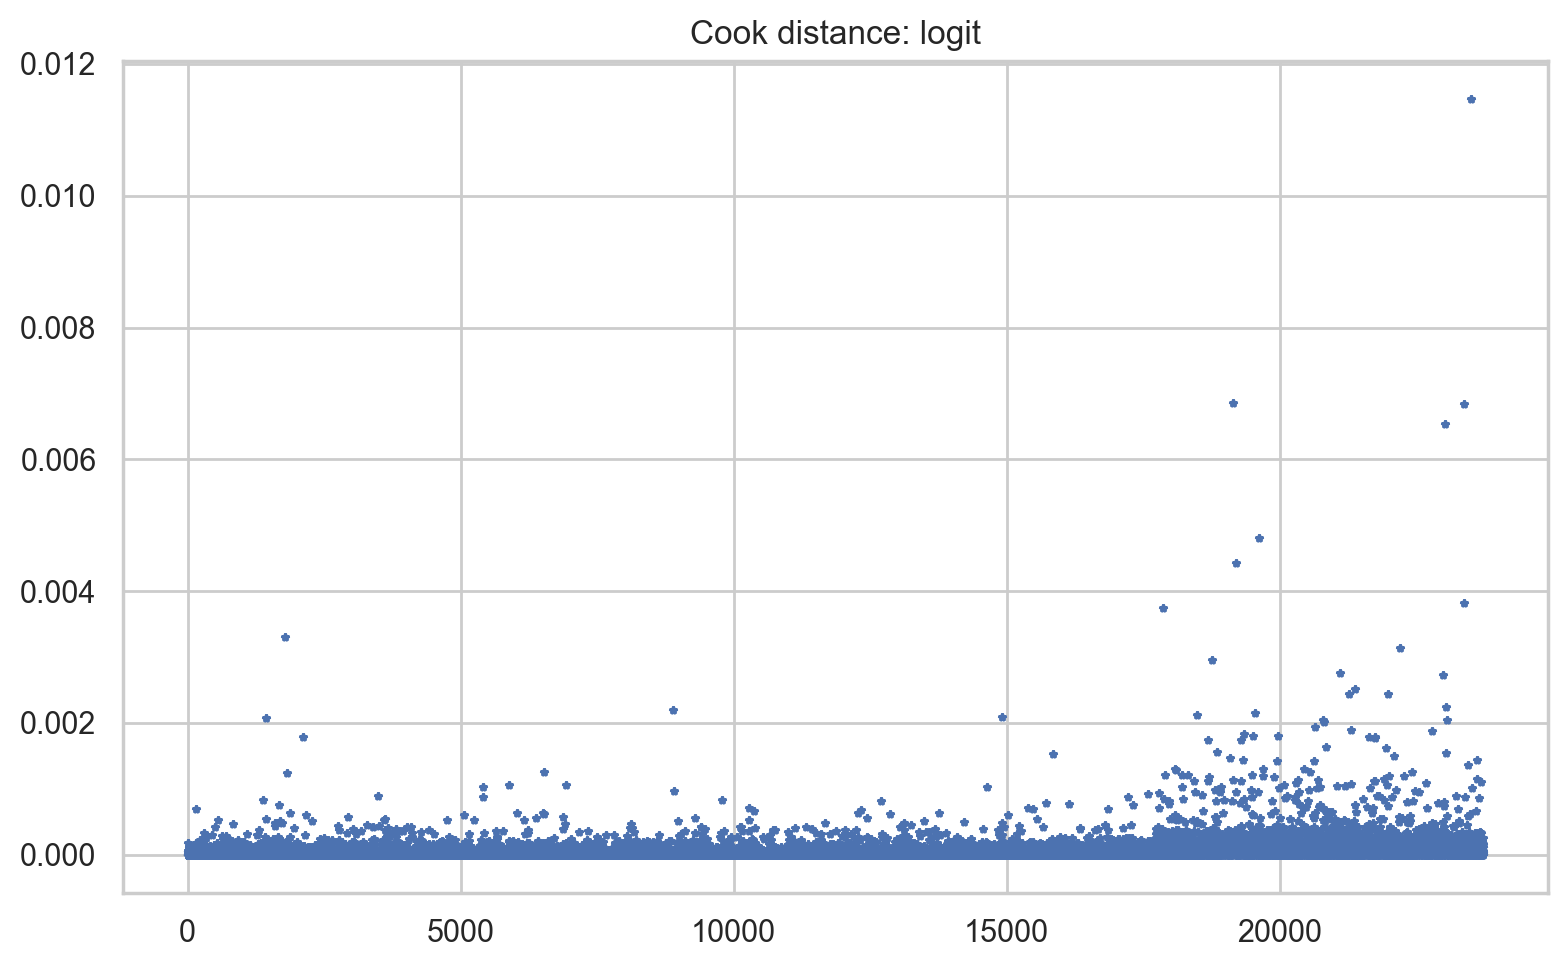

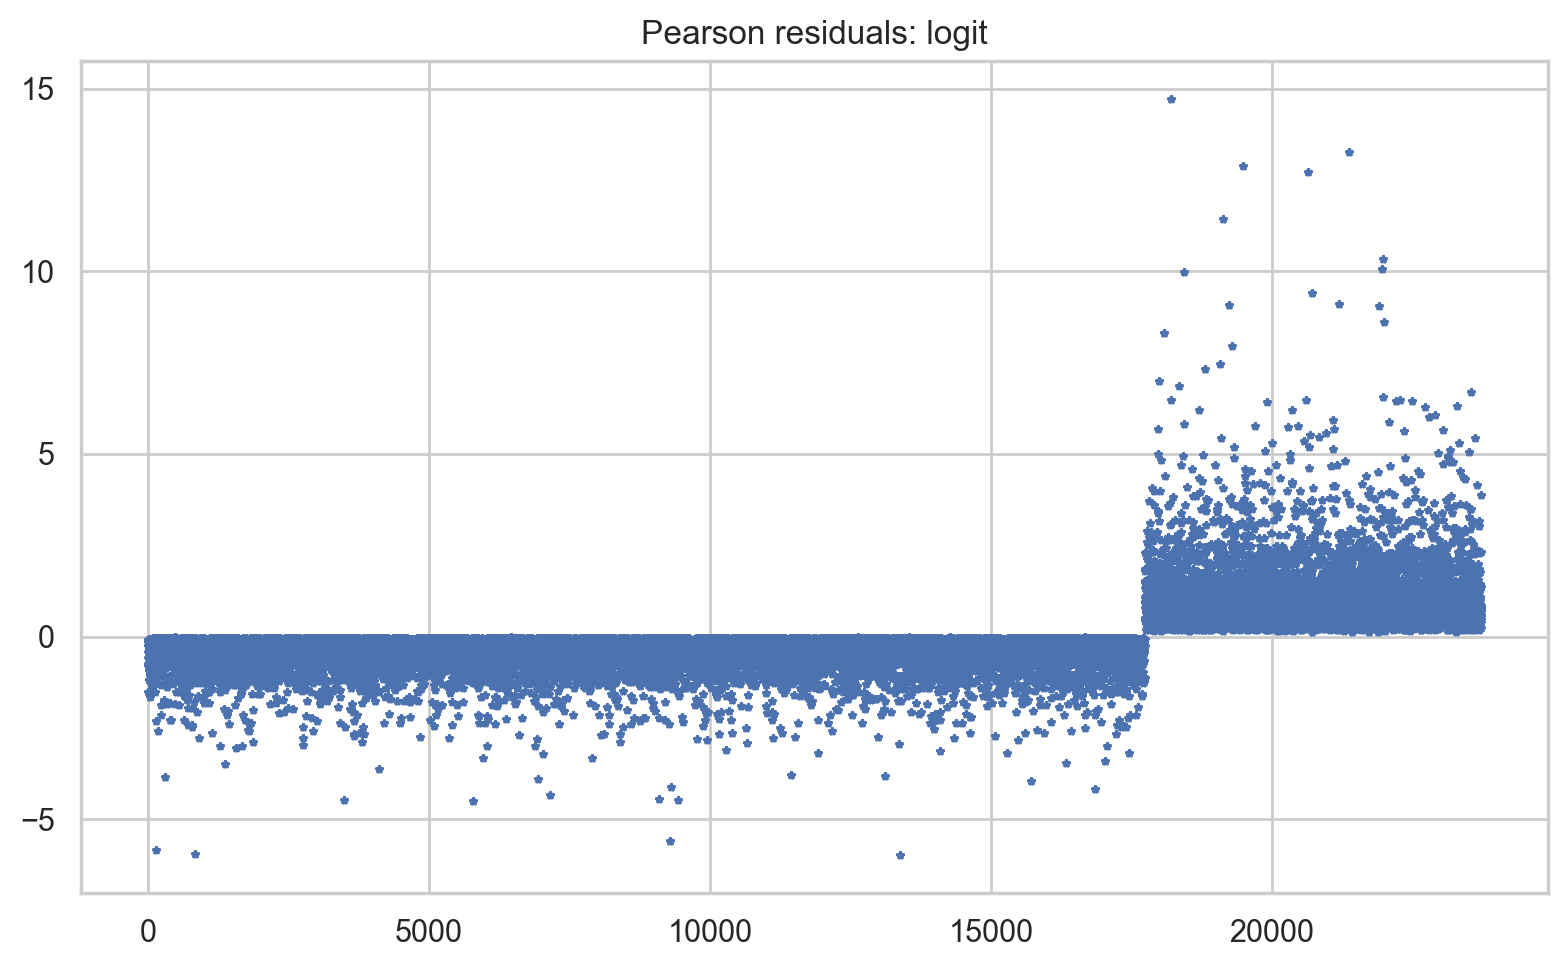

logit: Cook > 1 count = 0
logit: |Pearson| > 3 count = 306

[logit] CM @ 0.5
[[4039  396]
 [ 626  872]]
              precision    recall  f1-score   support

           0      0.866     0.911     0.888      4435
           1      0.688     0.582     0.631      1498

    accuracy                          0.828      5933
   macro avg      0.777     0.746     0.759      5933
weighted avg      0.821     0.828     0.823      5933

[logit] Optimal cutpoint (Youden): 0.2255
[[3328 1107]
 [ 219 1279]]
              precision    recall  f1-score   support

           0      0.938     0.750     0.834      4435
           1      0.536     0.854     0.659      1498

    accuracy                          0.777      5933
   macro avg      0.737     0.802     0.746      5933
weighted avg      0.837     0.777     0.790      5933



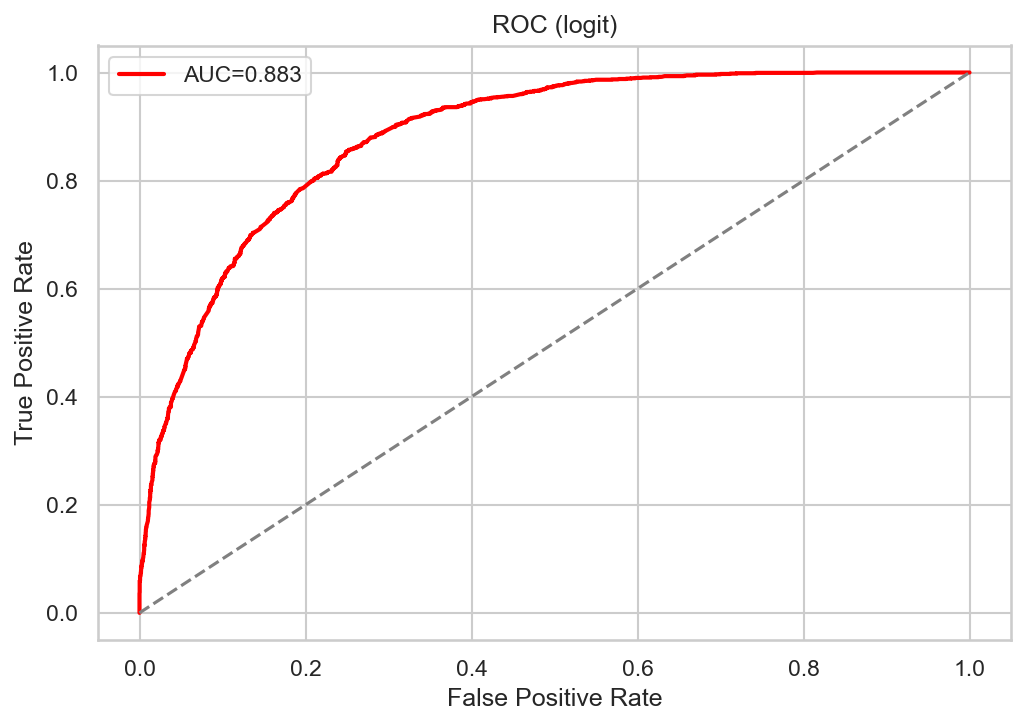

In [16]:
adult_logit = smf.glm(
    formula=formula_full,
    data=train,
    family=sm.families.Binomial(link=sm.families.links.logit()),
).fit()

print(adult_logit.summary())
print(f"BIC: {adult_logit.bic:.3f}")

for term in ["C(region)", "C(workclass_grp)", "C(race)"]:
    reduced_formula = formula_full.replace(f" + {term}", "")
    reduced_model = smf.glm(
        formula=reduced_formula,
        data=train,
        family=sm.families.Binomial(link=sm.families.links.logit()),
    ).fit()
    lr, dfd, p = likelihood_ratio_test(adult_logit, reduced_model)
    print(f"Remove {term}: LR={lr:.3f}, df={dfd:.0f}, p={p:.6g}")

summarize_diagnostics(adult_logit, "logit", "cook_logit.png", "pearson_logit.png")
pred_prob_logit = adult_logit.predict(test)
evaluate_model(test, pred_prob_logit, "logit", "red")

## Probit modelis

Remove C(region): LR=15.143, df=3, p=0.00169845
Remove C(workclass_grp): LR=4.649, df=2, p=0.0978273
Remove C(race): LR=29.762, df=4, p=5.47081e-06
                 Generalized Linear Model Regression Results                  
Dep. Variable:                 income   No. Observations:                23731
Model:                            GLM   Df Residuals:                    23709
Model Family:                Binomial   Df Model:                           21
Link Function:                 probit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -8592.0
Date:                Sun, 15 Mar 2026   Deviance:                       17184.
Time:                        23:11:24   Pearson chi2:                 2.21e+04
No. Iterations:                     8   Pseudo R-squ. (CS):             0.3337
Covariance Type:            nonrobust                                         
                                                              

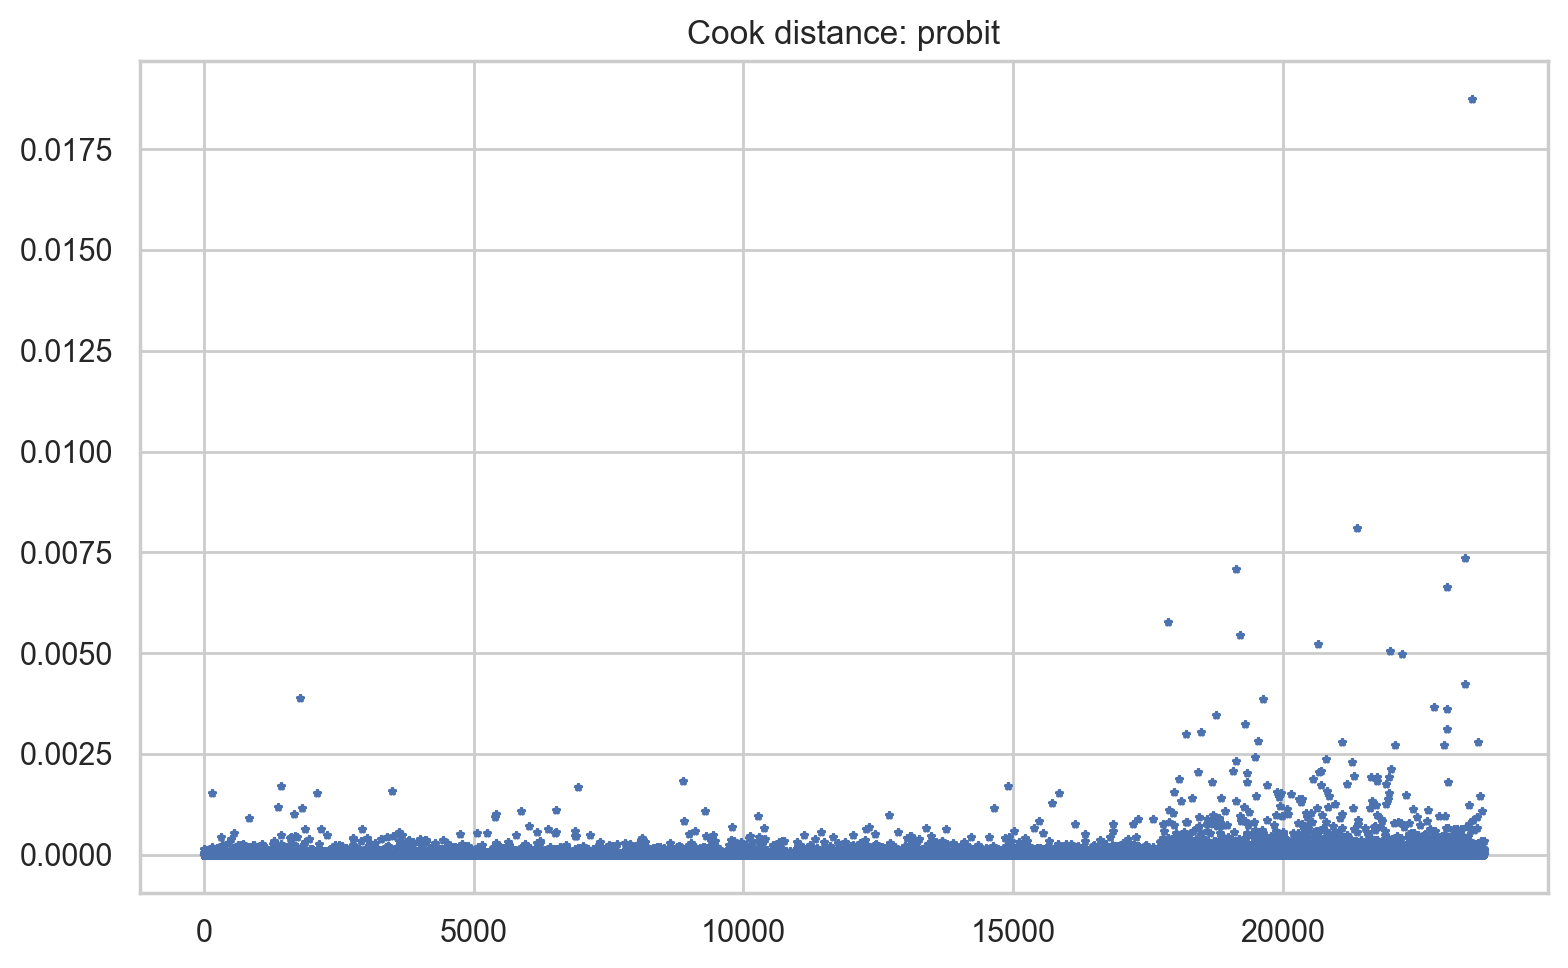

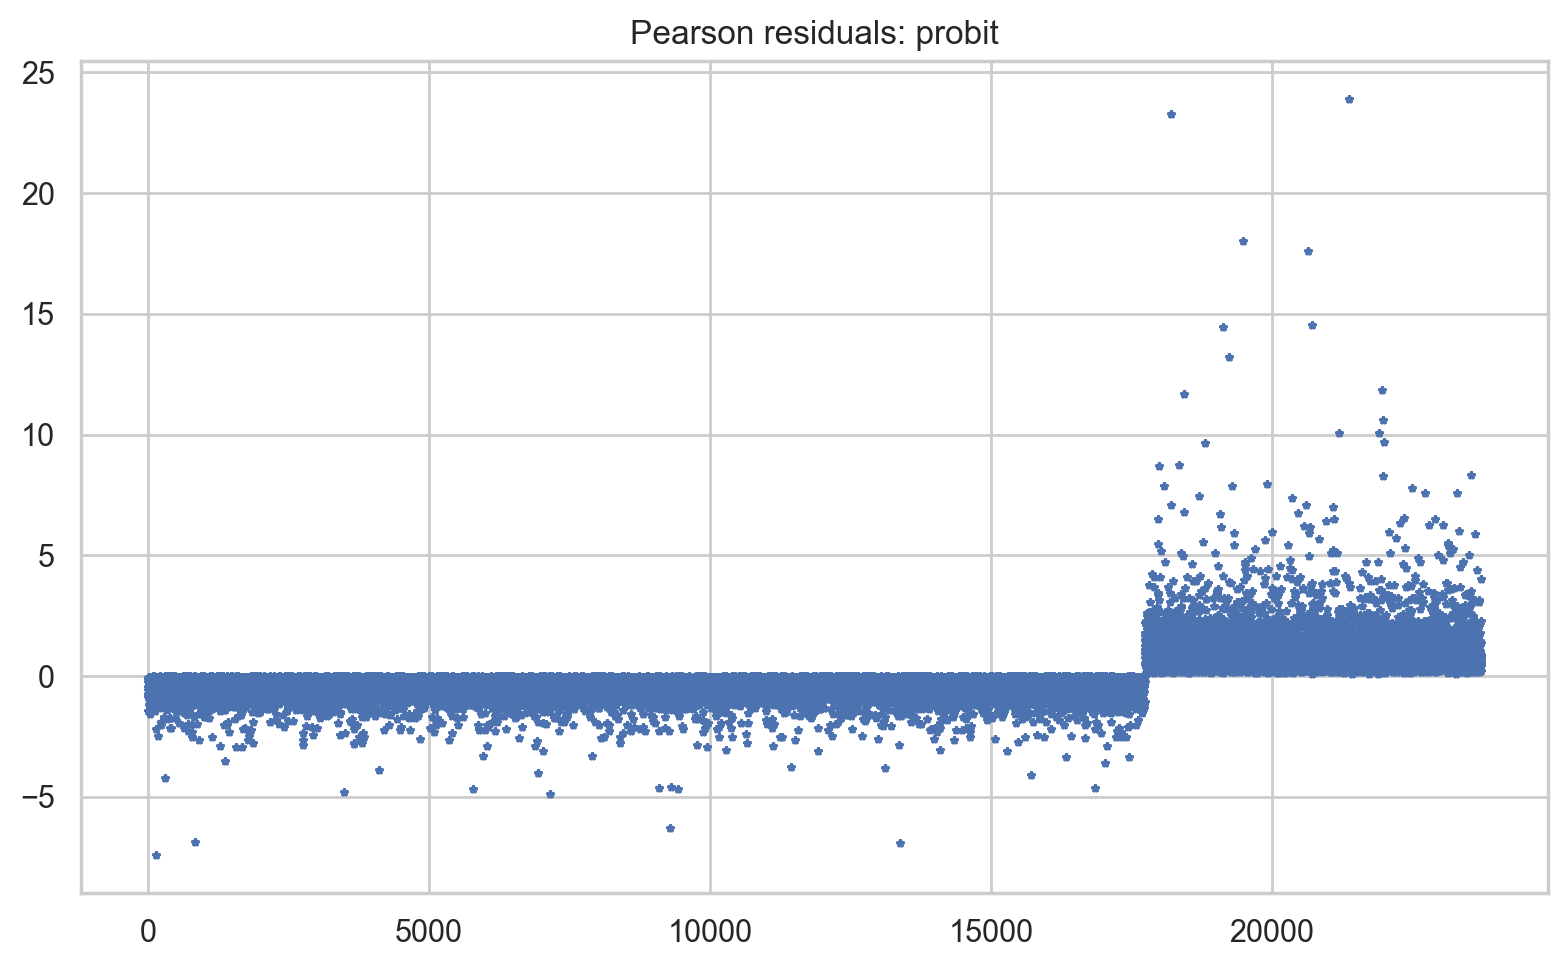

probit: Cook > 1 count = 0
probit: |Pearson| > 3 count = 287

[probit] CM @ 0.5
[[4035  400]
 [ 628  870]]
              precision    recall  f1-score   support

           0      0.865     0.910     0.887      4435
           1      0.685     0.581     0.629      1498

    accuracy                          0.827      5933
   macro avg      0.775     0.745     0.758      5933
weighted avg      0.820     0.827     0.822      5933

[probit] Optimal cutpoint (Youden): 0.2287
[[3293 1142]
 [ 209 1289]]
              precision    recall  f1-score   support

           0      0.940     0.743     0.830      4435
           1      0.530     0.860     0.656      1498

    accuracy                          0.772      5933
   macro avg      0.735     0.801     0.743      5933
weighted avg      0.837     0.772     0.786      5933



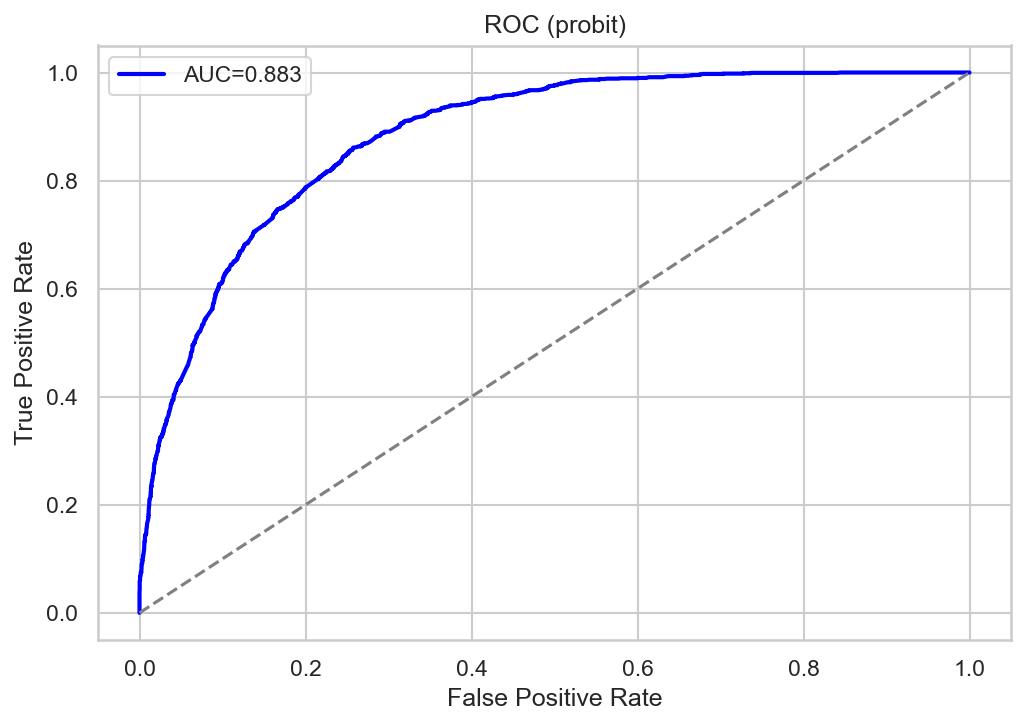

In [17]:
adult_probit_full = smf.glm(
    formula=formula_full,
    data=train,
    family=sm.families.Binomial(link=sm.families.links.probit()),
).fit()

for term in ["C(region)", "C(workclass_grp)", "C(race)"]:
    reduced_formula = formula_full.replace(f" + {term}", "")
    reduced_model = smf.glm(
        formula=reduced_formula,
        data=train,
        family=sm.families.Binomial(link=sm.families.links.probit()),
    ).fit()
    lr, dfd, p = likelihood_ratio_test(adult_probit_full, reduced_model)
    print(f"Remove {term}: LR={lr:.3f}, df={dfd:.0f}, p={p:.6g}")

formula_probit = formula_full.replace(" + C(workclass_grp)", "")
adult_probit = smf.glm(
    formula=formula_probit,
    data=train,
    family=sm.families.Binomial(link=sm.families.links.probit()),
).fit()

print(adult_probit.summary())
summarize_diagnostics(adult_probit, "probit", "cooks_probit.png", "pearsons_probit.png")
pred_prob_probit = adult_probit.predict(test)
evaluate_model(test, pred_prob_probit, "probit", "blue")

## Cloglog modelis

                 Generalized Linear Model Regression Results                  
Dep. Variable:                 income   No. Observations:                23731
Model:                            GLM   Df Residuals:                    23707
Model Family:                Binomial   Df Model:                           23
Link Function:                cloglog   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -8715.5
Date:                Sun, 15 Mar 2026   Deviance:                       17431.
Time:                        23:11:35   Pearson chi2:                 2.19e+04
No. Iterations:                    10   Pseudo R-squ. (CS):             0.3267
Covariance Type:            nonrobust                                         
                                                                          coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------

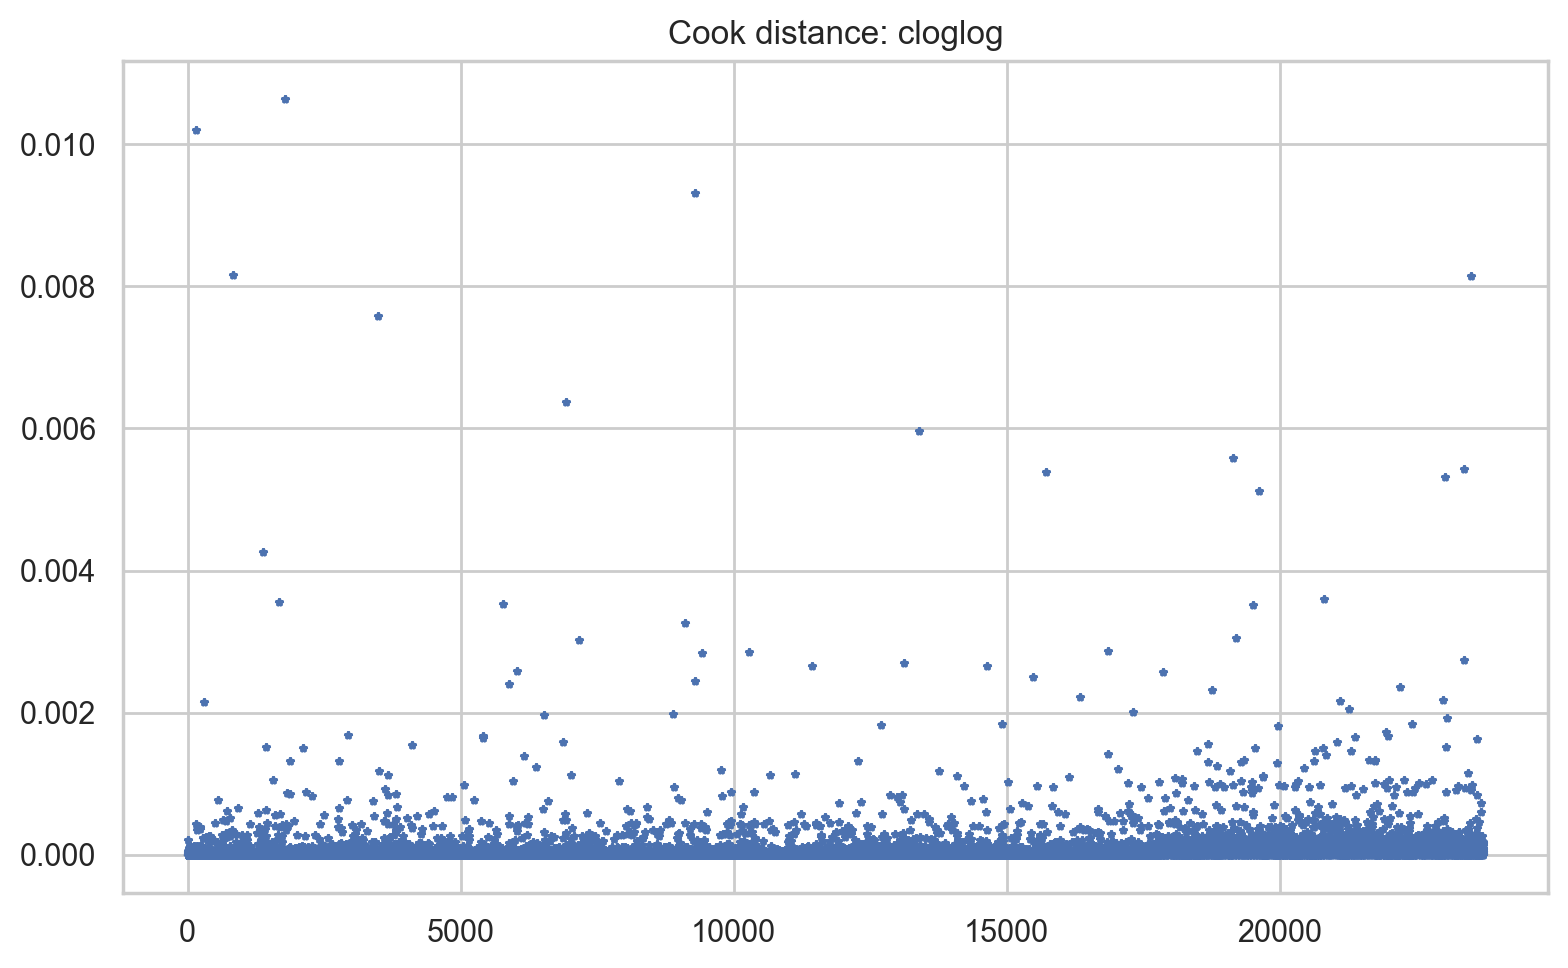

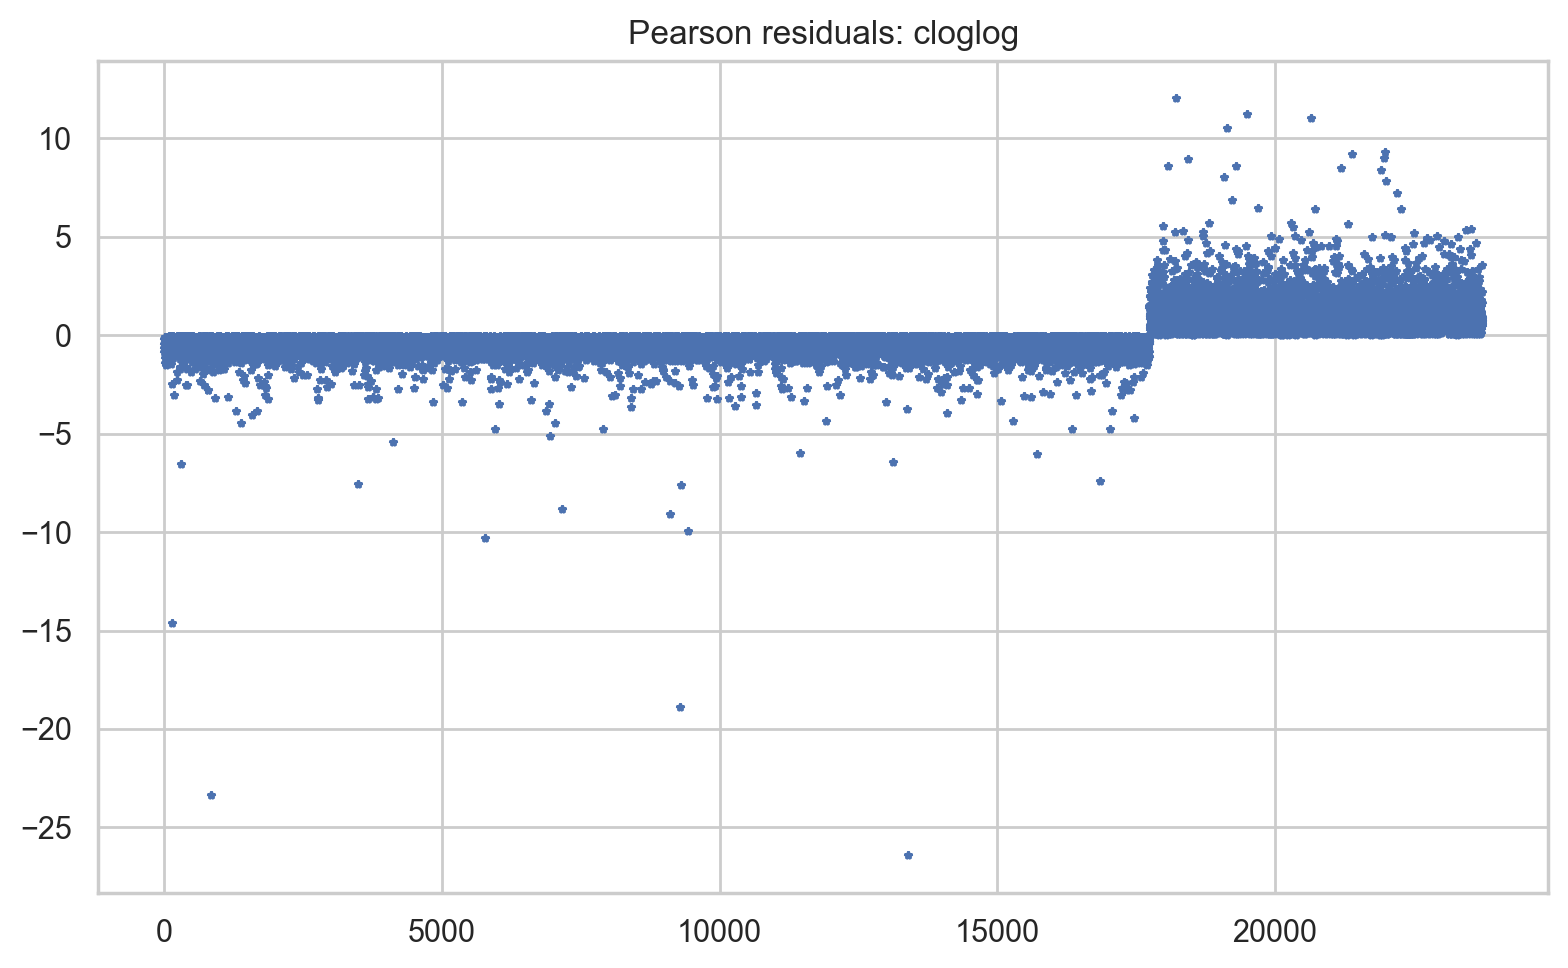

cloglog: Cook > 1 count = 0
cloglog: |Pearson| > 3 count = 307

[cloglog] CM @ 0.5
[[4085  350]
 [ 678  820]]
              precision    recall  f1-score   support

           0      0.858     0.921     0.888      4435
           1      0.701     0.547     0.615      1498

    accuracy                          0.827      5933
   macro avg      0.779     0.734     0.751      5933
weighted avg      0.818     0.827     0.819      5933

[cloglog] Optimal cutpoint (Youden): 0.2292
[[3383 1052]
 [ 248 1250]]
              precision    recall  f1-score   support

           0      0.932     0.763     0.839      4435
           1      0.543     0.834     0.658      1498

    accuracy                          0.781      5933
   macro avg      0.737     0.799     0.748      5933
weighted avg      0.834     0.781     0.793      5933



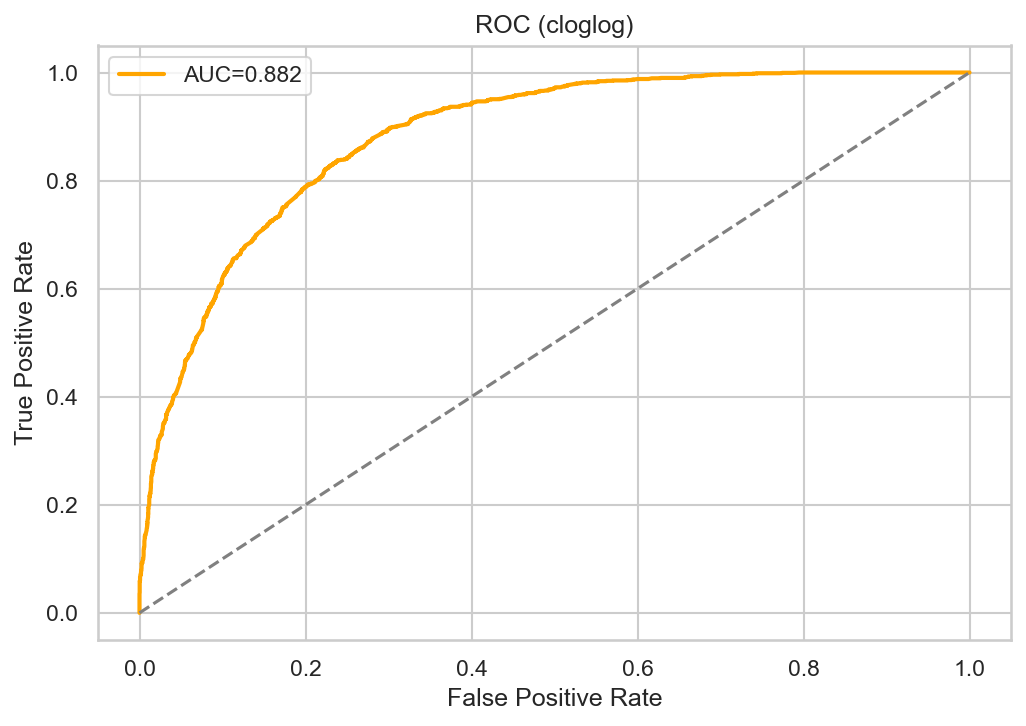

In [18]:
adult_cloglog = smf.glm(
    formula=formula_full,
    data=train,
    family=sm.families.Binomial(link=sm.families.links.cloglog()),
).fit()

print(adult_cloglog.summary())

for term in ["C(region)", "C(workclass_grp)", "C(race)"]:
    reduced_formula = formula_full.replace(f" + {term}", "")
    reduced_model = smf.glm(
        formula=reduced_formula,
        data=train,
        family=sm.families.Binomial(link=sm.families.links.cloglog()),
    ).fit()
    lr, dfd, p = likelihood_ratio_test(adult_cloglog, reduced_model)
    print(f"Remove {term}: LR={lr:.3f}, df={dfd:.0f}, p={p:.6g}")

summarize_diagnostics(adult_cloglog, "cloglog", "cook_cloglog.png", "pearson_cloglog.png")
pred_prob_cloglog = adult_cloglog.predict(test)
evaluate_model(test, pred_prob_cloglog, "cloglog", "orange")